Saving children_responses.csv to children_responses (9).csv
Saving parents_responses.csv to parents_responses (9).csv
Number of dyads (child–parent): N = 20

=== Means (± Standard deviation) ===
                    mean   std
child_usability     3.30  1.49
child_learning      2.95  1.23
child_engagement    4.28  0.99
child_independence  3.32  1.67
child_overall       3.36  1.18
par_usability       3.45  1.24
par_learning        3.44  0.89
par_engagement      3.32  0.62
par_independence    2.55  1.10
par_overall         3.34  0.66


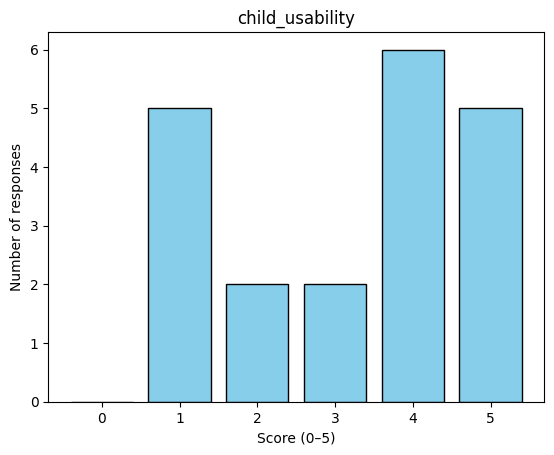

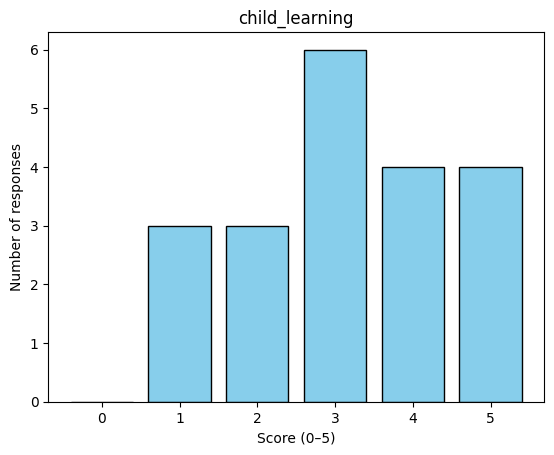

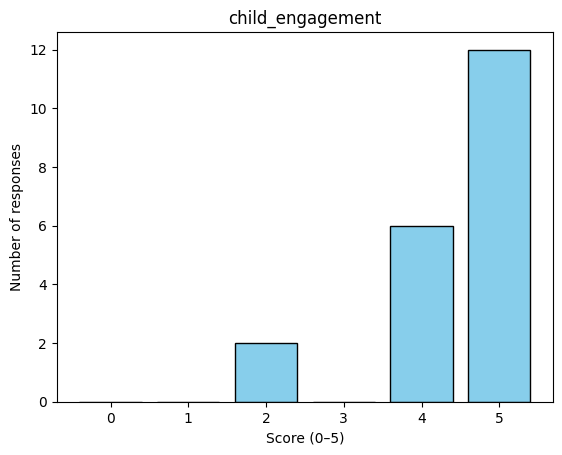

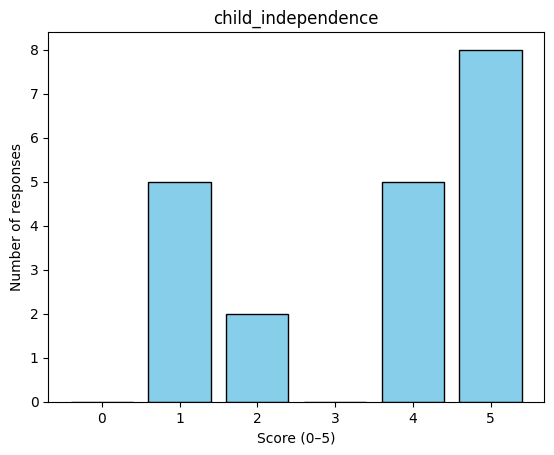

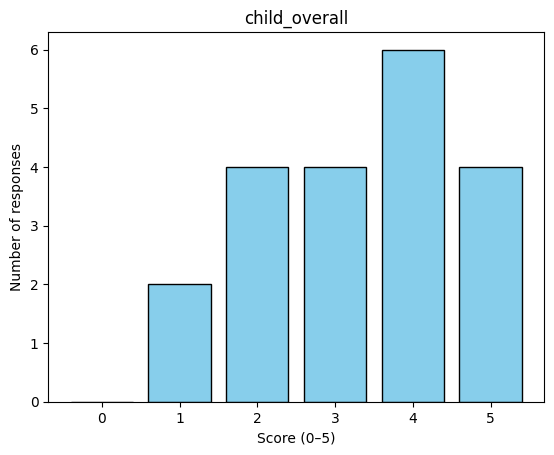

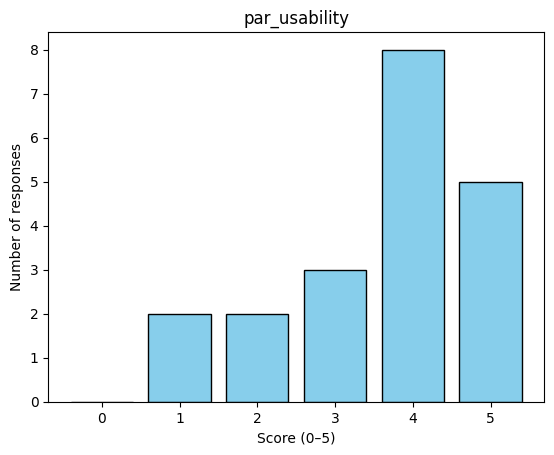

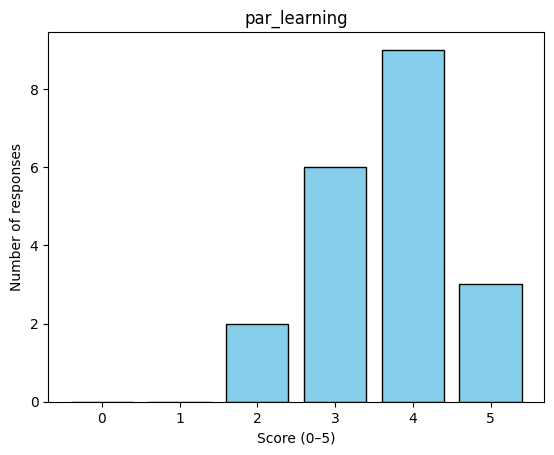

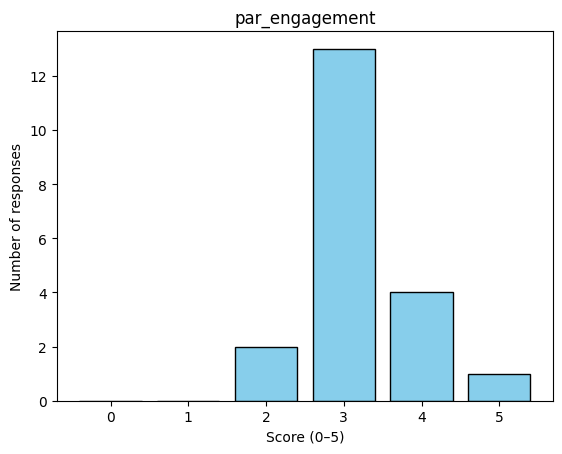

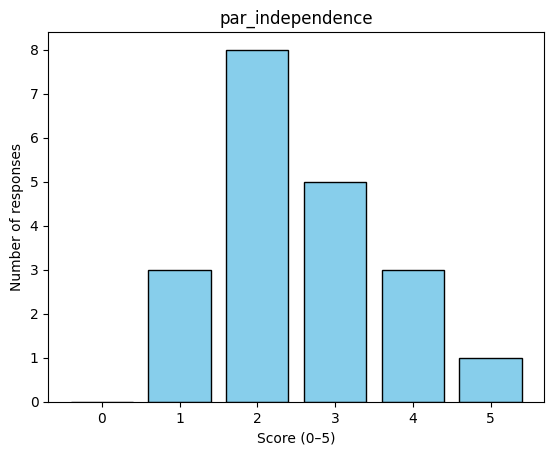

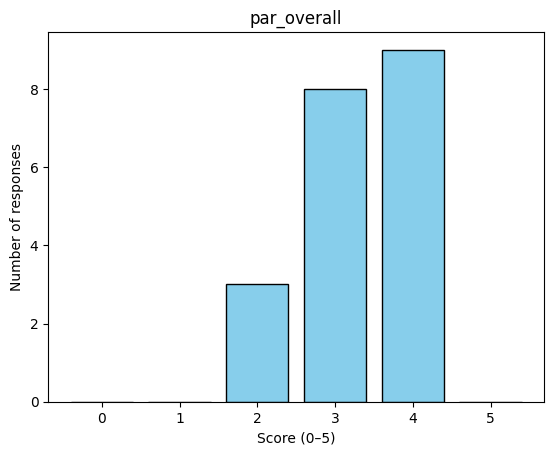


Cronbach's Alpha (Children, 10 items): 0.93
Cronbach's Alpha (Parents, 10 items): 0.75

Child–Parent correlation (overall score): r = 0.88, p = 0.000

=== Average overall scores by disorder (children) ===
disorder_c
AD                  3.33
ADHA                4.89
ADHD                3.93
ASD                 2.70
Dysphasia           4.78
dys_difficulties    3.86
Name: child_overall, dtype: float64

=== Average overall scores by disorder (parents) ===
disorder_p
AD                  3.70
ADHA                3.80
ADHD                3.47
ASD                 3.07
Dysphasia           4.10
dys_difficulties    3.55
Name: par_overall, dtype: float64

✅ Results exported: /content/results_summary_stats.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =============================================================================
# STATISTICAL ANALYSIS (WITHOUT AI) - CHILDREN & PARENTS QUESTIONNAIRES
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr



from google.colab import files

# --------------------------
# 1) Upload the data
# --------------------------
uploaded = files.upload()

# =========================
# 2) Load the data
# =========================
children = pd.read_csv('/content/children_responses.csv')
parents  = pd.read_csv('/content/parents_responses.csv')

child_qs = [f'Q{i}' for i in range(1, 11)]
parent_qs = [f'Q{i}' for i in range(1, 11)]

# =========================
# 3) Utility functions
# =========================
def mean_index(df, cols, new_name):
    """Compute a simple average across a set of questions (keeps 0 values)."""
    df[new_name] = df[cols].mean(axis=1)
    return df

def cronbach_alpha(items_df):
    """Compute Cronbach's alpha for internal consistency."""
    items = items_df.dropna(axis=0, how='any').to_numpy(dtype=float)
    k = items.shape[1]
    if k < 2:
        return np.nan
    var_sum = items.var(axis=0, ddof=1).sum()
    var_total = items.sum(axis=1).var(ddof=1)
    if var_total == 0:
        return np.nan
    return (k / (k - 1)) * (1 - var_sum / var_total)

def hist_0to5(series, title):
    """Histogram of responses (0–5), with bars centered on integers."""
    plt.figure()
    bins = np.arange(-0.5, 6.5, 1)
    plt.hist(series, bins=bins, rwidth=0.8, align="mid", color="skyblue", edgecolor="black")
    plt.title(title)
    plt.xlabel('Score (0–5)')
    plt.ylabel('Number of responses')
    plt.xticks(range(0,6))
    plt.show()

# =========================
# 4) Index creation
# =========================

# IMPORTANT: Question Q1 (children) is ignored because no child used the VR headset.
# This prevents bias in the results.

# Children
children = mean_index(children, ['Q2','Q4','Q5'], 'child_usability')
children = mean_index(children, ['Q3','Q6','Q7','Q8'], 'child_learning')
children = mean_index(children, ['Q9','Q10'], 'child_engagement')   # Q1 excluded
children = mean_index(children, ['Q5','Q7'], 'child_independence')
children = mean_index(children, ['Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10'], 'child_overall')  # Q1 excluded

# Parents (unchanged)
parents = mean_index(parents, ['Q2','Q4'], 'par_usability')
parents = mean_index(parents, ['Q4','Q5','Q6','Q8'], 'par_learning')
parents = mean_index(parents, ['Q1','Q3','Q10'], 'par_engagement')
parents = mean_index(parents, ['Q7'], 'par_independence')
parents = mean_index(parents, parent_qs, 'par_overall')

# =========================
# 5) Merge children–parents
# =========================
df = pd.merge(children, parents, on='participant_id', suffixes=('_c','_p'))
print(f"Number of dyads (child–parent): N = {len(df)}")

# =========================
# 6) Descriptive statistics
# =========================
indices = [
    'child_usability','child_learning','child_engagement','child_independence','child_overall',
    'par_usability','par_learning','par_engagement','par_independence','par_overall'
]

print("\n=== Means (± Standard deviation) ===")
desc = df[indices].agg(['mean','std']).T.round(2)
print(desc)

for col in indices:
    hist_0to5(df[col], title=col)

# =========================
# 7) Reliability (Cronbach's Alpha)
# =========================
# Here we keep all original questions Q1–Q10
# but it must be specified in your report that Q1 is not included in the children's indices.
alpha_child = cronbach_alpha(df[[f'Q{i}_c' for i in range(1,11)]])
alpha_par   = cronbach_alpha(df[[f'Q{i}_p' for i in range(1,11)]])
print(f"\nCronbach's Alpha (Children, 10 items): {alpha_child:.2f}")
print(f"Cronbach's Alpha (Parents, 10 items): {alpha_par:.2f}")

# =========================
# 8) Child–Parent correlation
# =========================
r, p = pearsonr(df['child_overall'], df['par_overall'])
print(f"\nChild–Parent correlation (overall score): r = {r:.2f}, p = {p:.3f}")

# =========================
# 9) Comparison by disorder
# =========================
print("\n=== Average overall scores by disorder (children) ===")
print(df.groupby('disorder_c')['child_overall'].mean().round(2))

print("\n=== Average overall scores by disorder (parents) ===")
print(df.groupby('disorder_p')['par_overall'].mean().round(2))

# =========================
# 10) Export results
# =========================
out_cols = [
    'participant_id','disorder_c','age_c',
    'child_overall','par_overall',
    'child_usability','child_learning','child_engagement','child_independence',
    'par_usability','par_learning','par_engagement','par_independence'
]
df[out_cols].to_csv('/content/results_summary_stats.csv', index=False)
print("\n Results exported: /content/results_summary_stats.csv")
files.download('/content/results_summary_stats.csv')
